# 4. Disordered Systems

A piece of magnetic material exposed to an increasing external field H(t) will magnetize and display an hysteresis loop (see Figure). If one takes the derivative of the loop one observed aeries of sharp jumps, or avalanches (see inset). These avalanches arise as magnetic domain walls in the material are pushed by the external field through a rugged potential energy landscape due to irregularities and impurities in the magnet. The magnetic signal resulting from these random avalanches is called Barkhausen noise .

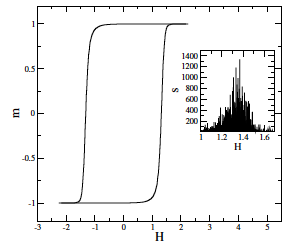

One can model this system with a non-equilibrium lattice model, the random  eld Ising model. The Hamiltonian or energy function for the
model is
$$\mathcal{H} = -\sum_{\langle i,j \rangle}Js_i s_j
-\sum_i(H+h_i)s_i, $$
where the spins $s_i = \pm 1$ lie on a square or cubic lattice with periodic boundary conditions. The coupling and the external field H are as in the traditional Ising model (explored in Section 2). The disorder
in the magnet is incorporated using the random field $h_i$, which is independently chosen at each lattice site from a Gaussian probability distribution of standard deviation $R$:

$$\rho(h)=\frac{1}{\sqrt{2\pi}R}\exp\left(-\frac{h^2}{2R^2}\right)$$

Here we are not interested in thermal equilibrium, but the opposite ex-
treme: we set the temperature to zero and change the field. We start with all spins pointing down, and adiabatically (infinitely slowly) increase $H(t)$ from $-\infty$
to $\infty$.

The rules for evolving the spin configuration are simple: each spin flips over when doing so would decrease the energy. This occurs at site i when the local field at that site ($f_i$) changes sign or:
$$s_i =\text{sign}(f_i)=\text{sign}(J\sum_j s_j  + h_i +H).$$


## The brute force algorithm
On the computer, changing the external  field infinitely slowly is easy. To start a new avalanche (or the first avalanche), one searches for the 
unflipped spin that is next to flip, jumps the  field H to just enough to 
ip it, and propagates the avalanche, as follows:

(1) Find the triggering spin i for the next avalanche, which is the unflipped site with the largest internal field $f_i$.

(2) Increment the external  field H to minus this internal field, and push the spin onto a first-in first-out queue.
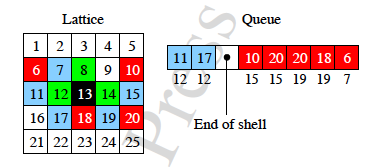

(3) Pop the top spin off the queue.

(4) If the spin has not been flipped, flip it and
push all un flipped neighbors with positive local fields onto the queue.

(5) While there are spins on the queue, repeat from step (3).

(6) Repeat from step (1) until all the spins are flipped.


#### Exercise 4.1 
- Write a function InitLattice to set up lattices s[m][n] and h[m][n] on the computer. (If you do three dimensions, add an extra index to the arrays.) Fill the former with down-spins (-1) and the latter with random  fields (real numbers chosen from the distribution above). 

- Write a function FlipSpin for the lattice, which given i and j flips the spin from s = -1 to s = +1 (complaining if it is already fliipped). 

- Write a function NeighborsUp which calculates the number of up-neighbors for the spin (implementing the periodic boundary conditions).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

In [3]:
def InitLattice(m,n,R):
    """ 
    Function to set up a lattice of size nxm and set the spins
    to -1 and chose Gaussian random fields with variance R

    Returns:
    s,h
    """
    s = np.ones((m, n)) * (-1)
    rng = np.random.default_rng()
    h = rng.normal(0, R, (m, n))

    return s, h

In [4]:
def FlipSpin(i,j,s):
    """ 
    Function to flip spin at i,j from the matrix s 
    if the spin was not already flipped.
    
    flag=1 if the spin was unflipped
    flag=0 if the spin was flipped

    Returns: s, flag
    """
    if s[i, j] < 0:
        flag = 1
        s[i, j] = (-1) * s[i, j] 
    else:
        flag = 0
    return s, flag

In [5]:
def NeighborsUp(i,j,s):
    """ 
    Function that counts the number of up spins n_up that are neighbors 
    of i,j in the matrix s. It implements periodic boundary condition
    along both directions.

    Returns: number of up spins
    """
    M = s.shape[0]
    N = s.shape[1]

    horizontal_edges = [((i - 1) % M, j), ((i + 1) % M, j)]
    vertical_edges = [(i, (j - 1) % N), (i, (j + 1) % N)]
    edges = horizontal_edges + vertical_edges

    n_up = sum([1 for i, j in edges if s[i, j] > 0])
    return n_up

#### Exercise 4.2 
Write a function BruteForceNextAvalanche for step (1), which checks the local fields of all of the unflipped spins, and returns the location of the next to flip.

In [6]:
def BruteForceNextAvalanche(s,h,J):
    """ function to check the local fields of all of the unflipped spins 
    Input: spins s, random fields h, coupling J
    Returns: i,j coordinates of the next spin to flip and the value that H should be increased to flip it
    """
    m, n = s.shape
    max_f_int = -np.inf
    best_coords = (None, None)

    for i in range(m):
        for j in range(n):
            if s[i, j] == -1:
                # sum(s_j) can be derived from NeighborsUp:
                # sum = (number of up) - (number of down)
                n_up = NeighborsUp(i, j, s)
                n_down = 4 - n_up
                internal_field = J * (n_up - n_down) + h[i, j]
                
                if internal_field > max_f_int:
                    max_f_int = internal_field
                    best_coords = (i, j)
    
    i, j = best_coords
    H = -max_f_int
    return i, j, H

#### Exercise 4.3
Write a function PropagateAvalanche that propagates an avalanche given the triggering spin, steps (3)-(5), coloring the spins that are flipped within
the same avalanche with the same color.

Run a 300x300 system at $R = 1.4$, $0.9$, and $0.7$ and and display the avalanches.

Here is an example of what the a final map of avalanches might look like. It is in B&W, but you should use colors.

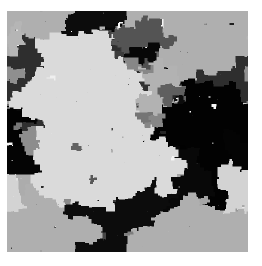



In [7]:
from collections import deque

def PropagateAvalanche(s, h, i, j, H, J, avalanche_map, avalanche_id):
    """function that propagates an avalanche given the triggering spin at i,j
    coloring the spins that are flipped"""
    M, N = s.shape
    queue = deque([(i, j)])
    
    while queue:
        curr_i, curr_j = queue.popleft()
        
        if s[curr_i, curr_j] == 1:
            continue
            
        # Flip and Color
        FlipSpin(curr_i, curr_j, s)
        avalanche_map[curr_i, curr_j] = avalanche_id
        
        # Check neighbors
        for di, dj in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            ni, nj = (curr_i + di) % M, (curr_j + dj) % N
            
            if s[ni, nj] == -1:
                n_up = NeighborsUp(ni, nj, s)
                n_down = 4 - n_up
                f_local = J * (n_up - n_down) + h[ni, nj] + H
                
                if f_local >= 0:
                    queue.append((ni, nj))

Starting simulation for R = 1.4...
Starting simulation for R = 0.9...
Starting simulation for R = 0.7...


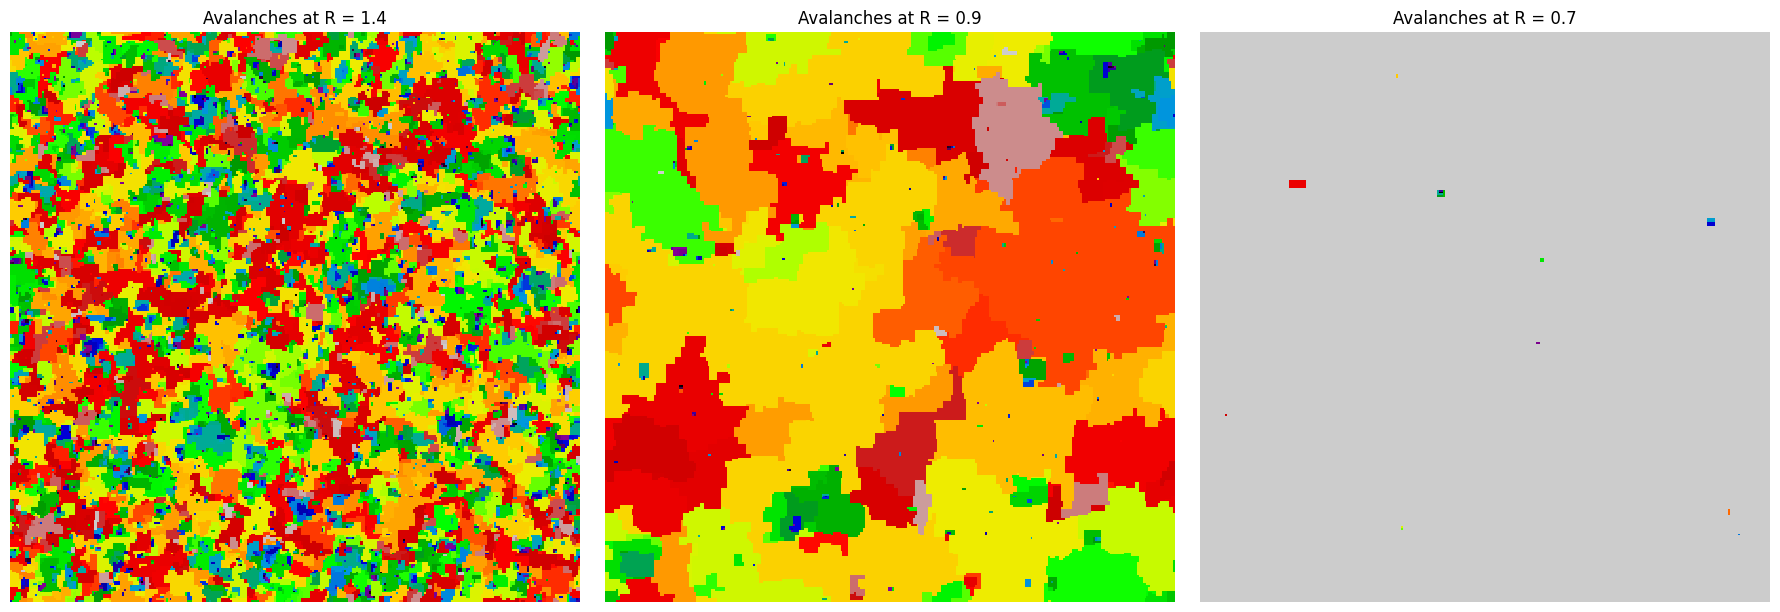

In [8]:
m, n = 300, 300
R_values = [1.4, 0.9, 0.7]
J = 1

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, R in zip(axes, R_values):
    print(f"Starting simulation for R = {R}...")
    s, h = InitLattice(m, n, R)
    avalanche_map = np.zeros((m, n))
    avalanche_id = 1
    
    # Continue until all spins are +1
    while np.any(s == -1):
        # Step 1: Find trigger
        i, j, H = BruteForceNextAvalanche(s, h, J)
        
        # Step 3-5: Propagate
        PropagateAvalanche(s, h, i, j, H, J, avalanche_map, avalanche_id)
        
        avalanche_id += 1
    
    im = ax.imshow(avalanche_map, cmap='nipy_spectral', interpolation='nearest')
    ax.set_title(f"Avalanches at R = {R}")
    ax.axis('off')

plt.tight_layout()
plt.show()

#### Exercise 4.4 

There are lots of properties that one might wish to measure about this system: avalanche sizes, avalanche correlation functions, hysteresis loop shapes, average pulse shapes during avalanches. It can get ugly if you put all of these measurements inside the inner loop of your code. Instead, we suggest that you try the subject/observer design pattern: each time a spin is flipped, and each time an
avalanche is finished, the subject (our simulation) notifies the list of observers.

Build a MagnetizationObserver, which stores an internal magnetization starting at $-N$, adding two to it whenever it is notifed. Build an AvalancheSizeObserver, which keeps track of the growing size of the current avalanche after each spin  flip, and adds the final size to a histogram of all previous avalanche sizes when the avalanche ends.

Set up NotifySpinFlip and NotifyAvalancheEnd function for your simulation, and add the two observers appropriately. Plot the magnetization curve $M(H)$ and the avalanche size distribution histogram $D(S)$ for the three systems you ran for exercise 4.3


In [ ]:
# Observer classes
from collections import Counter
 
class MagnetizationObserver:
    # Tracks the magnetization
    def __init__(self, N_total):
        self.M = -N_total          # all spins initially down → M = -N
        self.M_history = []
        self.H_history = []
 
    def on_spin_flip(self, H):
        self.M += 2                # one spin: -1 → +1, so ΔM = +2
        self.M_history.append(self.M)
        self.H_history.append(H)
 
    def on_avalanche_end(self):
        pass                      
 
 
class AvalancheSizeObserver:
    # Tracks the growing size of the current avalanche after each spin flip

    def __init__(self):
        self.current_size = 0
        self.histogram = Counter()   # size S → number of avalanches of that size

    def on_spin_flip(self, H):
        self.current_size += 1

    def on_avalanche_end(self):
        if self.current_size > 0:
            self.histogram[self.current_size] += 1   # add to histogram
        self.current_size = 0

In [ ]:
# Notification helpers
 
def NotifySpinFlip(observers, H):
    # Notify the observers after a spin flip
    for obs in observers:
        obs.on_spin_flip(H)
 
 
def NotifyAvalancheEnd(observers):
    # Notify the observers after an avalanche end
    for obs in observers:
        obs.on_avalanche_end()
 
 
# Updated PropagateAvalanche - adds optional observers arg
 
def ObservedPropagateAvalanche(s, h, i, j, H, J, avalanche_map, avalanche_id, observers=None):

    M, N = s.shape
    queue = deque([(i, j)])
 
    while queue:
        ci, cj = queue.popleft()
 
        if s[ci, cj] == 1:          # already flipped
            continue
 
        FlipSpin(ci, cj, s)
        avalanche_map[ci, cj] = avalanche_id
 
        if observers:
            NotifySpinFlip(observers, H)
 
        for di, dj in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            ni, nj = (ci + di) % M, (cj + dj) % N
            if s[ni, nj] == -1:
                n_up = NeighborsUp(ni, nj, s)
                if J * (2 * n_up - 4) + h[ni, nj] + H >= 0:
                    queue.append((ni, nj))
 
    if observers:
        NotifyAvalancheEnd(observers)

In [ ]:
m, n = 300, 300
R_values = [1.4, 0.9, 0.7]
J = 1
 
results = {}
 
for R in R_values:
    print(f"Running R = {R} …", flush=True)
    s, h = InitLattice(m, n, R)
    avalanche_map = np.zeros((m, n))
    avalanche_id  = 1
 
    mag_obs  = MagnetizationObserver(m * n)
    size_obs = AvalancheSizeObserver()
    observers = [mag_obs, size_obs]
 
    while np.any(s == -1):
        i, j, H = BruteForceNextAvalanche(s, h, J)
        ObservedPropagateAvalanche(s, h, i, j, H, J, avalanche_map, avalanche_id, observers)
        avalanche_id += 1
 
    results[R] = {"mag": mag_obs, "size": size_obs, "amap": avalanche_map}
    print(f"  done - {avalanche_id - 1} avalanches.")

Running R = 1.4 …
  done – 5807 avalanches.
Running R = 0.9 …
  done – 469 avalanches.
Running R = 0.7 …
  done – 5 avalanches.


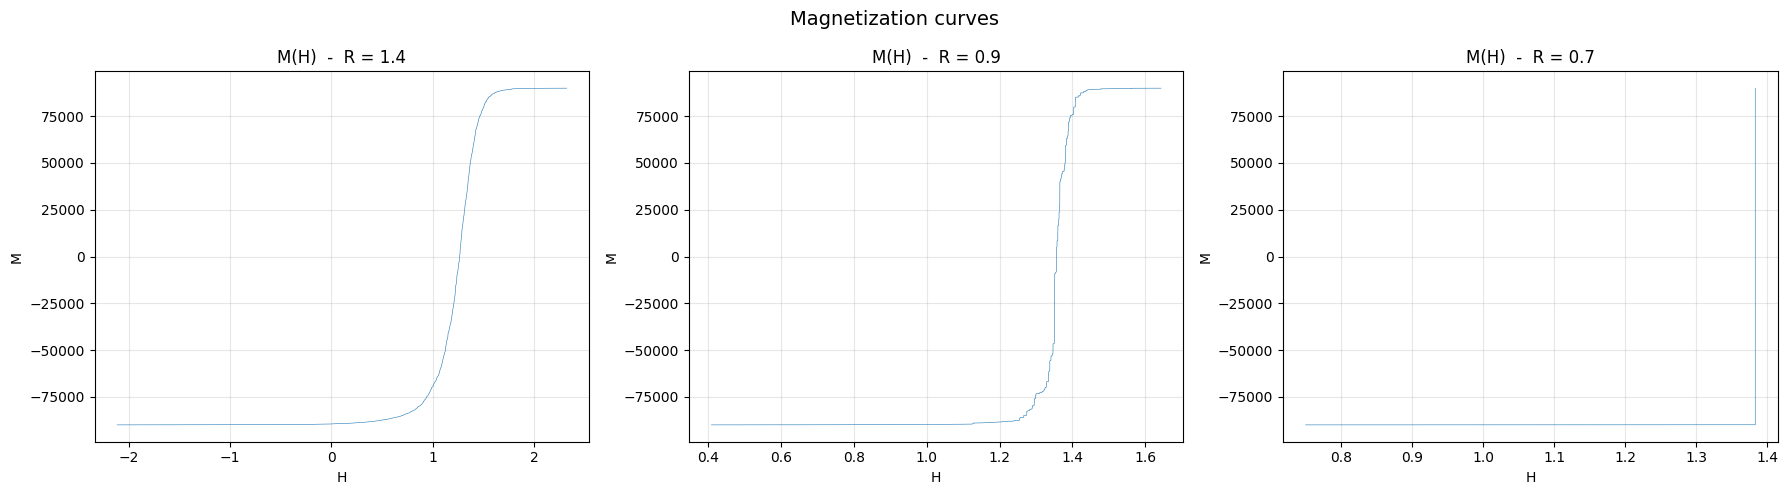

In [ ]:
# Plot M(H) curves
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, R in zip(axes, R_values):
    mag = results[R]["mag"]
    ax.plot(mag.H_history, mag.M_history, linewidth=0.4)
    ax.set_title(f"M(H)  -  R = {R}")
    ax.set_xlabel("H")
    ax.set_ylabel("M")
    ax.grid(True, alpha=0.3)
plt.suptitle("Magnetization curves", fontsize=14)
plt.tight_layout()
plt.show()

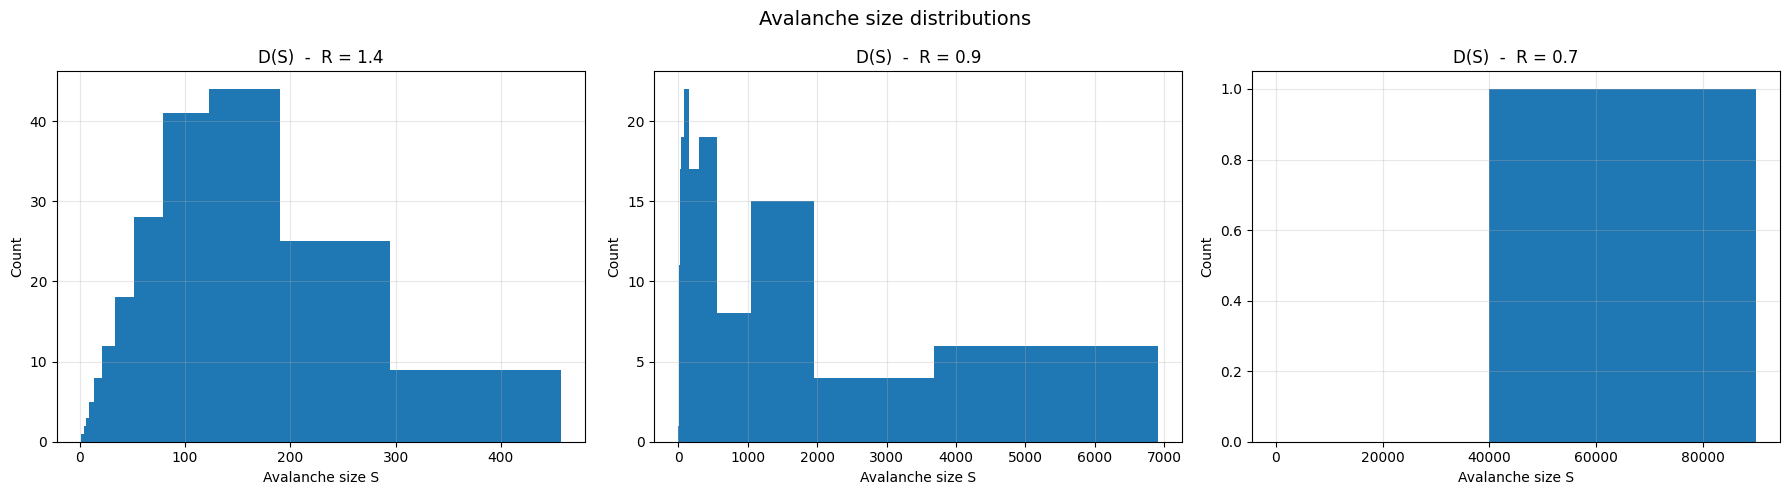

In [ ]:
# Plot D(S) avalanche-size distributions
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, R in zip(axes, R_values):
    hist = results[R]["size"].histogram          # Counter: {S: count}
    sizes  = np.array(sorted(hist.keys()))
    counts = np.array([hist[s] for s in sizes])

    # plot as histograms:
    # logbins = np.geomspace(sizes.min(), sizes.max(), 15)
    # ax.hist(sizes, logbins)
    
    ax.loglog(sizes, counts, "o-", markersize=3)
    ax.set_title(f"D(S)  -  R = {R}")
    ax.set_xlabel("Avalanche size S")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3, which="both")
plt.suptitle("Avalanche size distributions", fontsize=14)
plt.tight_layout()
plt.show()

## The sorted list algorithm
The brute-force algorithm for finding the next avalanche for a system with $N$ spins takes a time of order $N$ per avalanche. Since there are roughly N avalanches the time for the brute-force algorithm scales as $N^2$. We can use a sorted list to speed op our algorithm.

We make a list of the spins in order of their random elds. Given a field range $(H,H+\Delta)$ in a lattice with z neighbors per site (4 in $d=2$), only those spins with random  fields in the range $JS + H < h_i < JS +(H +\Delta)$ need to be checked, for the $z+1$ possible fields $JS = (-Jz,-J(z+1), ..., Jz)$, from the
neighbors. We can keep track of the locations in thesorted list of the $z + 1$ possible next spins to flip. The spins can be sorted in time $N \log N$, which is
practically indistinguishable from linear in $N$, and a big improvement over the brute-force algorithm.

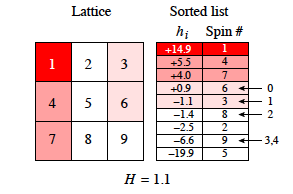

#### Exercise 4.5
Write a sorted list algorithm according to the following steps:

1) Define an array nextPossible[nUp], which points to the location in the sorted list of the next spin that would  flip if it had nUp neighbors. Initially, all the elements of nextPossible[nUp] point to the spin with the largest random  field $h_i$.
2) From the z + 1 spins pointed to by nextPossible, choose the one nUpNext with
the largest internal  fleld in nUp - nDown + $h_i$ = 2 nUp - z +$h_i$. Do not check values of nUp for which the pointer has fallen off  the end of the list; use a variable stopNUP.
3) Move the pointer nextPossible[nUpNext] to the next spin on the sorted list. If you have fallen o  the end of the list, decrement stopNUP.
4) If the spin nUpNext has exactly the right number of up-neighbors, flip it, increment the external field H(t), and start the next avalanche. Otherwise go back to step (2).

Implement the sorted list algorithm for  finding the next avalanche. Notice the pause at the beginning of the simulation; most of the computer time ought to be spent sorting the list. Compare the timing with your brute-force algorithm for a moderate system size, where the brute-force algorithm is slightly painful to run. 

In [14]:
# Build the sorted list
 
def InitSortedList(h):
    """
    Return all lattice positions as a list sorted by h[i,j] descending.
    The sorted order never changes: pointers just advance through it.
    """
    M, N = h.shape
    coords = [(i, j) for i in range(M) for j in range(N)]
    coords.sort(key=lambda ij: h[ij[0], ij[1]], reverse=True)
    return coords

In [ ]:
# Sorted-list trigger finder
 
def SortedListNextAvalanche(s, h, J, sorted_coords, nextPossible):
    """
    Find the next avalanche trigger,
    where 'advances' is the number of steps the pointers move.
 
    Parameters
    ----------
    sorted_coords : list of (i,j) sorted by h descending, built once.
    nextPossible  : length-(z+1) list of int pointers, mutated in place.
                    nextPossible[nUp] is the current position for nUp up-neighbours.
    """
    z = 4
    n_total = len(sorted_coords)
 
    # Which nUp slots still have candidates left in the sorted list
    valid = [nextPossible[nUp] < n_total for nUp in range(z + 1)]
 
    while any(valid):
 
        # Step 2 – pick the nUp whose current candidate has the
        # largest internal field  f = J*(2·nUp − z) + h[candidate]
        best_nUp  = -1
        best_field  = -np.inf
        for nUp in range(z + 1):
            if not valid[nUp]:
                continue
            ci, cj = sorted_coords[nextPossible[nUp]]
            field = J * (2 * nUp - z) + h[ci, cj]
            if field > best_field:
                best_field = field
                best_nUp = nUp
 
        ci, cj = sorted_coords[nextPossible[best_nUp]]
 
        # Step 3 – advance this nUp's pointer
        nextPossible[best_nUp] += 1
        if nextPossible[best_nUp] >= n_total:
            valid[best_nUp] = False
 
        # Step 4 – accept only if the spin is unflipped AND really
        # has exactly best_nUp up-neighbours right now
        if s[ci, cj] == -1 and NeighborsUp(ci, cj, s) == best_nUp:
            return ci, cj, -best_field   # H_next = −f_internal
 
    return            # all spins are up

In [ ]:
def run_simulation(m, n, R, J=1, use_sorted=False):
    s, h = InitLattice(m, n, R)
    amap = np.zeros((m, n))
    mag  = MagnetizationObserver(m * n)
    siz  = AvalancheSizeObserver()
    obs  = [mag, siz]
    aid  = 1
 
    if use_sorted:
        sorted_coords = InitSortedList(h)
        nextPossible  = [0] * (4 + 1)       # all pointers start at index 0
 
    while np.any(s == -1):
        if use_sorted:
            i, j, H = SortedListNextAvalanche(s, h, J, sorted_coords, nextPossible)
        else:
            i, j, H = BruteForceNextAvalanche(s, h, J)
        if i is None:
            break
        ObservedPropagateAvalanche(s, h, i, j, H, J, amap, aid, obs)
        aid += 1
 
    return mag, siz

In [17]:
# Timing comparison
import time
 
print(f"{'Size':>6}  {'Brute (s)':>10}  {'Sorted (s)':>10}  {'Speedup':>8}")
print("-" * 42)
 
for size in [20, 40, 60, 80, 100, 300]:
    # fix seed for a fair comparison
    t0 = time.time()
    run_simulation(size, size, R=1.4, use_sorted=False)
    t_bf = time.time() - t0
 
    t0 = time.time()
    run_simulation(size, size, R=1.4, use_sorted=True)
    t_sl = time.time() - t0
 
    print(f"{size:>4}x{size:<4}  {t_bf:>10.3f}  {t_sl:>10.3f}  {t_bf/t_sl:>7.1f}x")

  Size   Brute (s)  Sorted (s)   Speedup
------------------------------------------
  20x20         0.003       0.003      1.3x
  40x40         0.069       0.011      6.4x
  60x60         0.325       0.022     14.8x
  80x80         0.814       0.038     21.4x
 100x100        2.317       0.058     40.0x
 300x300      207.706       0.676    307.1x
